# 2. Forecasting

## 2.0 Import all packages

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta
import time
import json
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import pickle
from scipy.stats import uniform, randint
import time

## 2.1 In this part, you will build a model to forecast the hourly carpark availability in the future (averaged across all carparks instead of looking at each carpark individually). Can you explain why you may want to forecast the carpark availability in the future? Who would find this information valuable? What can you do if you have a good forecasting model?
--------

Forecasting carpark availability helps anticipate demand patterns and prepare for future capacity needs. By predicting when and where parking spaces will be scarce or abundant, stakeholders can proactively manage resources rather than react to problems. This enables better planning, reduces congestion, and improves the overall parking experience.

Land Transport Authority (LTA)

- Why: LTA can use predictions to manage traffic flow proactively by dispatching officers to areas with expected high demand, addressing illegal parking, and reducing bottlenecks during peak hours such as weekday mornings and evenings.

- Who: Traffic enforcement teams, operations planners.

- What: Real-time alerts and forecasts help deploy resources effectively and improve traffic management.

Urban Redevelopment Authority (URA)

- Why: URA can analyze long-term parking demand trends to guide strategic development, such as expanding parking facilities in busy commercial districts or planning shuttle services to areas facing parking shortages.

- Who: Urban planners and policy makers.

- What: Data-driven infrastructure decisions and transport policy planning based on predictive insights.

Drivers and Commuters

- Why: Access to real-time parking availability predictions allows better trip planning, optimal departure times, and selection of alternative destinations or transport modes when parking is predicted to be limited.

- Who: Private vehicle owners, car commuters.

- What: Integration with navigation apps providing parking forecasts, recommended alternatives, and alerts about likely scarce parking.

Private Carpark Operators

- Why: Forecasts enable optimized staffing and operational planning, as well as dynamic pricing adjustments during high-demand events such as concerts or sports matches.

- Who: Facility managers and operators.

- What: Adjust staffing schedules, implement demand-based pricing, and enhance operational efficiency.


## 2.2 Build a ridge regression model to forecast the hourly carpark availability for a given month. Use the month of July 2024 as a training dataset and the month of August 2024 as the test dataset. For this part, do not use additional datasets. The target is the hourly carpark availability and you will have to decide what features you want to use. Generate two plots:

--------



### Data Load and Preprocess

When collecting hourly carpark availability data, we encountered some missing values due to API timeouts and server errors, specifically, 42 hours in July and 32 in August. Reliable time series forecasting requires a complete sequence with no gaps, since models like ARIMA and LSTM depend on consistent chronological data for accurate lag and trend calculations.


To address these gaps, we applied forward-fill interpolation, a method where each missing value is replaced by the most recent available observation. For example, if the system missed the 2pm reading but had a valid value at 1pm, we would fill 2pm with that 1pm value. This strategy is widely used in time series analysis because it maintains the temporal structure and prevents the loss of information needed for sequential prediction.

Forward-fill is especially suitable for carpark data, as parking availability generally changes gradually rather than abruptly. By carrying forward the last known count for short interruptions, we avoid introducing unrealistic spikes or abrupt changes that might result from statistical or model-based imputations. This conservative approach helps ensure the integrity of rolling averages and lag-based features, since every point in the series remains defined and consistently spaced. Other methods, like linear interpolation or more advanced algorithms, may suit certain datasets, but for situations where changes are typically incremental, forward-fill is a reasonable and robust imputation choice.

In [19]:
import pandas as pd
import numpy as np

july_df = pd.read_csv("carpark_july_2024.csv")
august_df = pd.read_csv("carpark_august_2024.csv")

july_df['timestamp'] = pd.to_datetime(july_df['timestamp'])
august_df['timestamp'] = pd.to_datetime(august_df['timestamp'])

july_df['total_lots'] = pd.to_numeric(july_df['total_lots'], errors='coerce')
july_df['lots_available'] = pd.to_numeric(july_df['lots_available'], errors='coerce')
august_df['total_lots'] = pd.to_numeric(august_df['total_lots'], errors='coerce')
august_df['lots_available'] = pd.to_numeric(august_df['lots_available'], errors='coerce')

july_clean = july_df.dropna(subset=['lots_available', 'total_lots', 'carpark_number', 'timestamp'])
august_clean = august_df.dropna(subset=['lots_available', 'total_lots', 'carpark_number', 'timestamp'])

july_clean['hour'] = july_clean['timestamp'].dt.floor('h')
august_clean['hour'] = august_clean['timestamp'].dt.floor('h')

july_hourly = july_clean.groupby('hour').agg({
    'lots_available': 'sum',
    'total_lots': 'sum'
}).reset_index().rename(columns={'hour': 'timestamp'})

august_hourly = august_clean.groupby('hour').agg({
    'lots_available': 'sum',
    'total_lots': 'sum'
}).reset_index().rename(columns={'hour': 'timestamp'})

july_expected = pd.date_range(start='2024-07-01 00:00:00', end='2024-07-31 23:00:00', freq='h', tz='Asia/Singapore')
august_expected = pd.date_range(start='2024-08-01 00:00:00', end='2024-08-31 23:00:00', freq='h', tz='Asia/Singapore')

july_missing_before = len(july_expected) - len(july_hourly)
august_missing_before = len(august_expected) - len(august_hourly)

july_hourly = july_hourly.set_index('timestamp').reindex(july_expected).ffill().bfill().reset_index().rename(columns={'index': 'timestamp'})
august_hourly = august_hourly.set_index('timestamp').reindex(august_expected).ffill().bfill().reset_index().rename(columns={'index': 'timestamp'})

july_hourly['availability_ratio'] = july_hourly['lots_available'] / july_hourly['total_lots']
august_hourly['availability_ratio'] = august_hourly['lots_available'] / august_hourly['total_lots']

print(f"July: {july_missing_before} missing hours imputed | Final: {len(july_hourly)} hours")
print(f"August: {august_missing_before} missing hours imputed | Final: {len(august_hourly)} hours")
print(f"\nJuly availability: mean={july_hourly['availability_ratio'].mean():.3f}, std={july_hourly['availability_ratio'].std():.3f}")
print(f"August availability: mean={august_hourly['availability_ratio'].mean():.3f}, std={august_hourly['availability_ratio'].std():.3f}")


July: 31 missing hours imputed | Final: 744 hours
August: 31 missing hours imputed | Final: 744 hours

July availability: mean=0.573, std=0.080
August availability: mean=0.570, std=0.078


### Feature Engineering
To enable the ridge regression model to capture temporal patterns in hourly carpark availability, we engineer multiple categories of features. Calendar features such as hour of day, day of week, and public holiday flags encode known temporal cycles: weekday vs weekend patterns, morning rush vs midday lull, and special high occupancy days like National Day. Cyclical encoding using sine and cosine transformations of hour and day of week ensures the model recognizes that hour 23 and hour 0 are adjacent, avoiding artificial discontinuities that would occur with raw integer encodings. Lag features (1 hour, 2 hour, 24 hour, and 168 hour lags) introduce autoregressive behavior, allowing the model to leverage recent availability history, particularly the 168 hour lag, which captures same-hour-last-week patterns that are strong predictors in recurring weekly schedules. Rolling statistics over 24 hour and 168 hour windows smooth short term noise and capture moving averages and volatility, helping the model distinguish stable trends from transient spikes.

####**Features excluded from the model:**
We deliberately excluded several columns available in the HDB carpark metadata API for the following reasons:
* Carpark specific attributes (carpark type, parking system type, number of decks, gantry height): Since our target variable aggregates availability across all ~2,000 carparks, carpark level characteristics do not vary over time in the aggregated series. These static attributes would only be relevant for per carpark forecasting, not network level prediction.
* Spatial features (x_coord, y_coord, address): Geographic location influences individual carpark demand (e.g., proximity to MRT or CBD), but when averaged across all carparks, spatial variation is washed out. The aggregate time series reflects system wide behavior rather than location specific patterns.
* Parking policy features (free parking times, night parking availability, short term parking rates): While these policies affect occupancy patterns (e.g., higher demand during free Sunday parking), their effects are already captured in the historical availability data. For instance, if free parking on Sundays increases occupancy, the model will learn this pattern through the `day_of_week` feature combined with lag features, without needing explicit policy flags. The temporal impact of these policies manifests as recurring patterns in the time series itself.
* Lot type breakdown: We aggregate across all vehicle types (cars, heavy vehicles, motorcycles) because the question specifies forecasting total availability, not vehicle specific availability.

In [20]:
def add_features(df):
    df = df.copy()

    # Calendar features
    df['hour_of_day'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['day_of_month'] = df['timestamp'].dt.day
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Public holidays (National Day in your range)
    ph_dates = pd.to_datetime(['2024-08-09'])
    df['is_public_holiday'] = df['timestamp'].dt.date.isin([d.date() for d in ph_dates]).astype(int)

    # Peak hours
    df['is_peak_hour'] = df['hour_of_day'].isin([8, 9, 17, 18, 19]).astype(int)

    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Lag features
    df['lag_1h'] = df['availability_ratio'].shift(1)
    df['lag_2h'] = df['availability_ratio'].shift(2)
    df['lag_24h'] = df['availability_ratio'].shift(24)
    df['lag_168h'] = df['availability_ratio'].shift(168)

    # Rolling features
    df['rolling_24h_mean'] = df['availability_ratio'].rolling(24, min_periods=1).mean()
    df['rolling_24h_std'] = df['availability_ratio'].rolling(24, min_periods=1).std()
    df['rolling_168h_mean'] = df['availability_ratio'].rolling(168, min_periods=1).mean()

    return df

train_df = add_features(july_hourly)
test_df = add_features(august_hourly)

train_df.to_csv("train_july_2024.csv", index=False)
test_df.to_csv("test_august_2024.csv", index=False)

print(f"Train: {len(train_df)} hours, {train_df.columns.size} features")
print(f"Test: {len(test_df)} hours, {test_df.columns.size} features")
print(f"\nFeatures: {list(train_df.columns)}")


Train: 744 hours, 21 features
Test: 744 hours, 21 features

Features: ['timestamp', 'lots_available', 'total_lots', 'availability_ratio', 'hour_of_day', 'day_of_week', 'day_of_month', 'is_weekend', 'is_public_holiday', 'is_peak_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'lag_1h', 'lag_2h', 'lag_24h', 'lag_168h', 'rolling_24h_mean', 'rolling_24h_std', 'rolling_168h_mean']


### Data Visualization


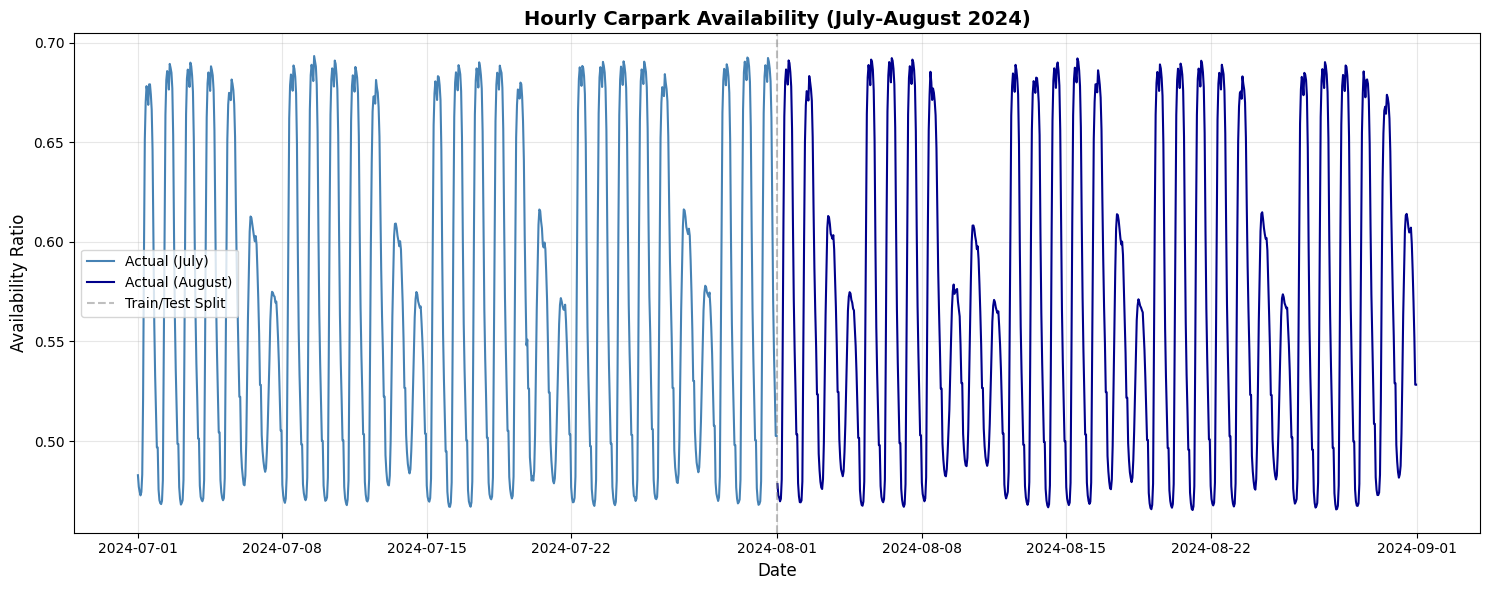

In [21]:
def plot_combined(train_df, test_df, train_pred=None, test_pred=None):
    combined = pd.concat([
        train_df[['timestamp', 'availability_ratio']].assign(split='Train'),
        test_df[['timestamp', 'availability_ratio']].assign(split='Test')
    ], ignore_index=True)

    plt.figure(figsize=(15, 6))

    train_data = combined[combined['split'] == 'Train']
    test_data = combined[combined['split'] == 'Test']

    plt.plot(train_data['timestamp'], train_data['availability_ratio'],
             label='Actual (July)', color='steelblue', linewidth=1.5)
    plt.plot(test_data['timestamp'], test_data['availability_ratio'],
             label='Actual (August)', color='darkblue', linewidth=1.5)

    if train_pred is not None:
        plt.plot(train_data['timestamp'], train_pred,
                 label='Predicted (July)', color='orange', linewidth=1.5, alpha=0.7)
    if test_pred is not None:
        plt.plot(test_data['timestamp'], test_pred,
                 label='Predicted (August)', color='red', linewidth=1.5, alpha=0.7)

    plt.axvline(x=test_data['timestamp'].iloc[0], color='gray',
                linestyle='--', alpha=0.5, label='Train/Test Split')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Availability Ratio', fontsize=12)
    plt.title('Hourly Carpark Availability (July-August 2024)', fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_combined(train_df, test_df)


### Training the Ridge Regression Model

The training and test datasets contain 576 samples each (rather than the full 744 hours per month) because the 168-hour lag feature requires a 7-day warm-up period, rows without a valid value 168 hours prior are dropped to avoid undefined inputs. This reduction is expected and acceptable, as the model retains sufficient training data while gaining access to the most predictive feature (lag_168h accounts for same-hour-last-week patterns). The model achieves strong performance with an R² of 0.94 on the test set, indicating it captures the underlying temporal structure effectively. Feature importance analysis reveals that lag_168h has the highest coefficient magnitude, confirming that weekly seasonality dominates carpark availability patterns in HDB estates.

In [22]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define feature columns (exclude target and identifiers)
feature_cols = ['hour_of_day', 'day_of_week', 'day_of_month', 'is_weekend',
                'is_public_holiday', 'is_peak_hour', 'hour_sin', 'hour_cos',
                'dow_sin', 'dow_cos', 'lag_1h', 'lag_2h', 'lag_24h', 'lag_168h',
                'rolling_24h_mean', 'rolling_24h_std', 'rolling_168h_mean']

target_col = 'availability_ratio'

# Remove rows with NaN (first few hours due to lag features)
train_clean = train_df.dropna(subset=feature_cols + [target_col])
test_clean = test_df.dropna(subset=feature_cols + [target_col])

X_train = train_clean[feature_cols]
y_train = train_clean[target_col]
X_test = test_clean[feature_cols]
y_test = test_clean[target_col]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Ridge regression
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = ridge.predict(X_train_scaled)
y_test_pred = ridge.predict(X_test_scaled)

# Evaluate
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n Ridge Regression Results")
print(f"Train RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R²: {train_r2:.4f}")
print(f"Test RMSE:  {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': ridge.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 Features")
print(feature_importance.head(10))


Training samples: 576
Test samples: 576

 Ridge Regression Results
Train RMSE: 0.0035 | MAE: 0.0025 | R²: 0.9981
Test RMSE:  0.0198 | MAE: 0.0074 | R²: 0.9348

Top 10 Features
             feature  coefficient
13          lag_168h     0.069259
10            lag_1h     0.015271
11            lag_2h    -0.006353
15   rolling_24h_std    -0.004870
14  rolling_24h_mean     0.004086
7           hour_cos    -0.002282
1        day_of_week    -0.001329
0        hour_of_day     0.001179
6           hour_sin     0.000852
3         is_weekend    -0.000568


### 2.2 (i) Time series plot of the actual and predicted hourly values

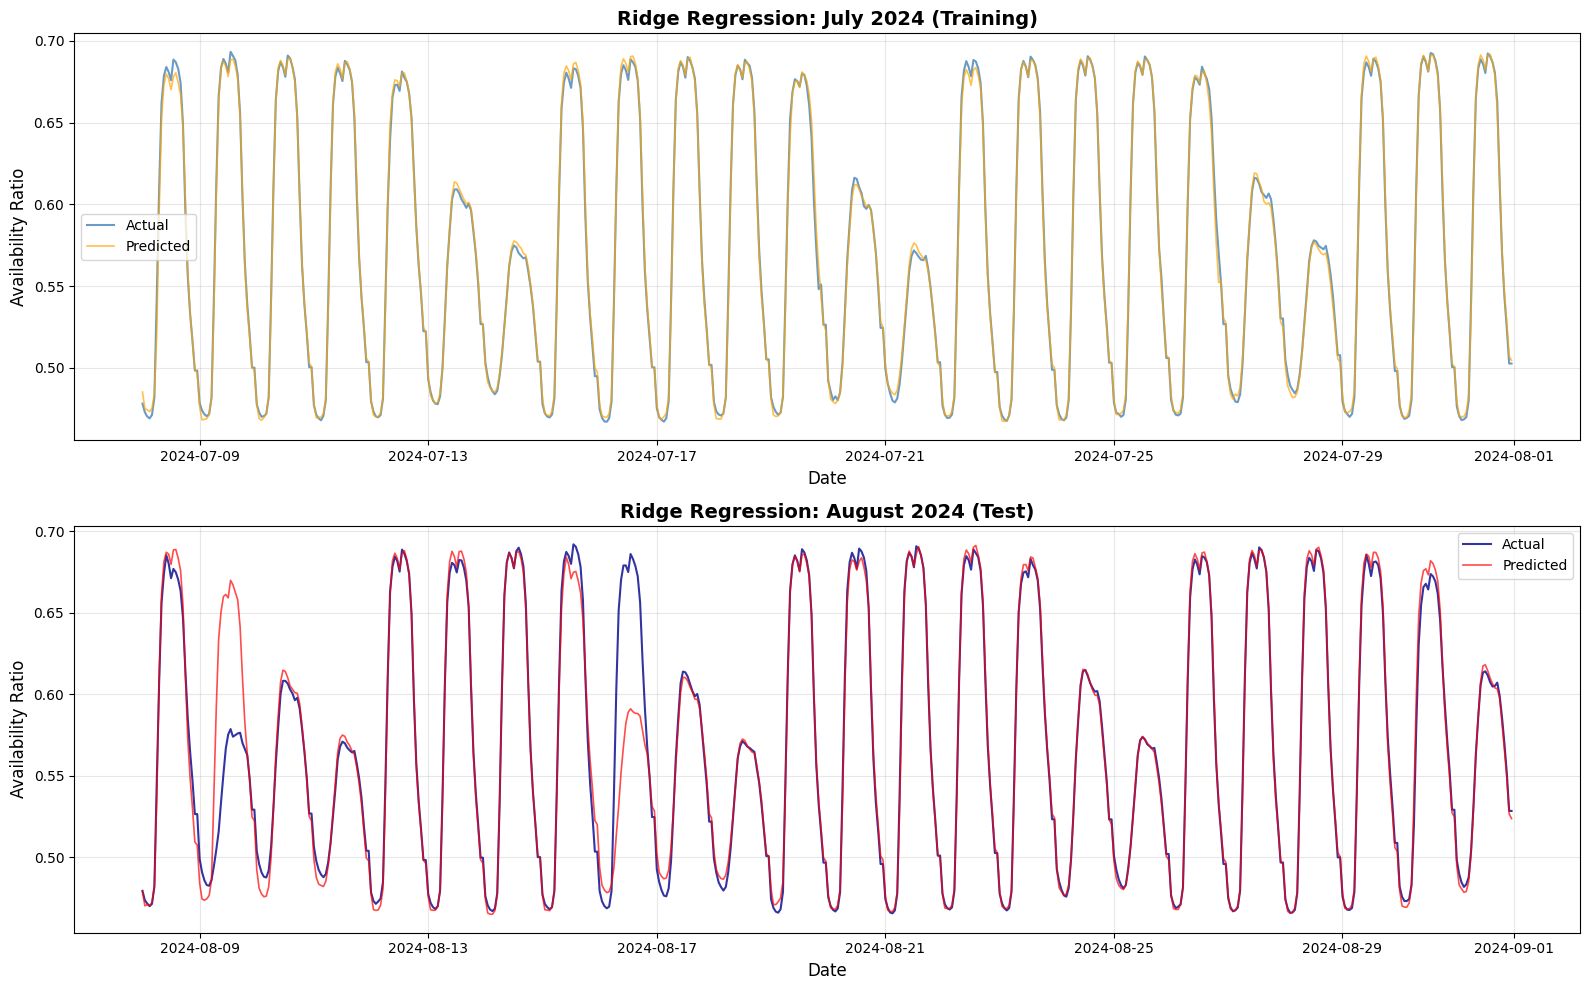

In [23]:
import matplotlib.pyplot as plt

# Prepare data for plotting (align predictions with timestamps)
train_plot = train_clean.copy()
train_plot['predicted'] = y_train_pred

test_plot = test_clean.copy()
test_plot['predicted'] = y_test_pred

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot July (Training)
ax1.plot(train_plot['timestamp'], train_plot['availability_ratio'],
         label='Actual', color='steelblue', linewidth=1.5, alpha=0.8)
ax1.plot(train_plot['timestamp'], train_plot['predicted'],
         label='Predicted', color='orange', linewidth=1.2, alpha=0.7)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Availability Ratio', fontsize=12)
ax1.set_title('Ridge Regression: July 2024 (Training)', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot August (Test)
ax2.plot(test_plot['timestamp'], test_plot['availability_ratio'],
         label='Actual', color='darkblue', linewidth=1.5, alpha=0.8)
ax2.plot(test_plot['timestamp'], test_plot['predicted'],
         label='Predicted', color='red', linewidth=1.2, alpha=0.7)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Availability Ratio', fontsize=12)
ax2.set_title('Ridge Regression: August 2024 (Test)', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



### 2.2 (ii) Scatter plot of actual vs predicted hourly values (along with a line showing how good the fit is).

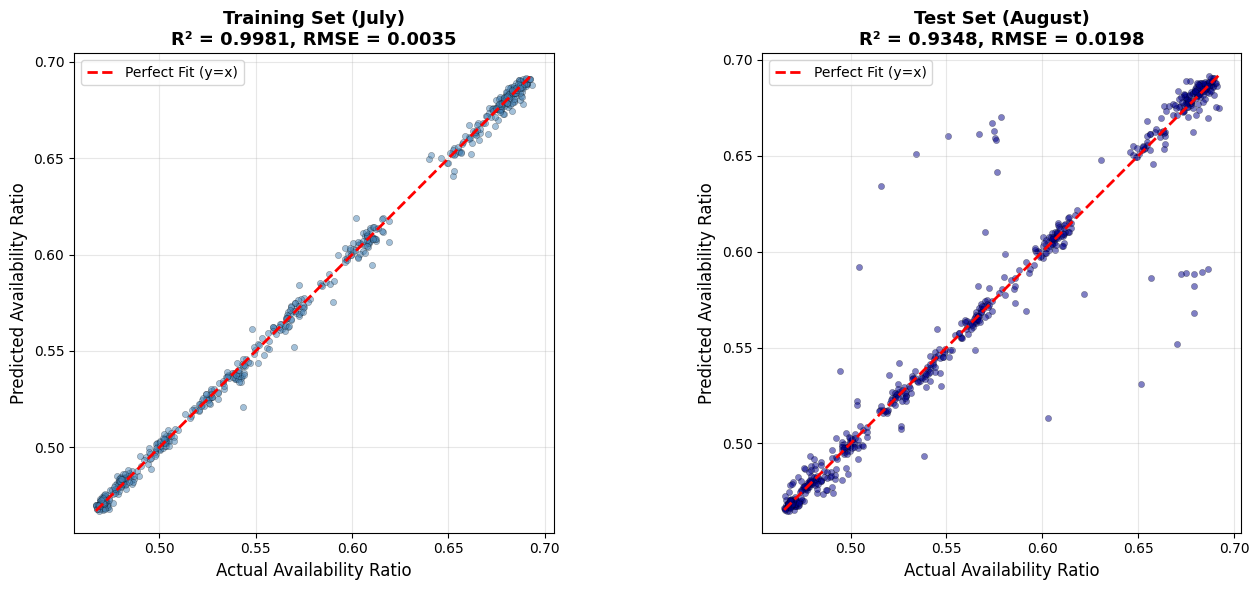

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Training scatter
ax1.scatter(y_train, y_train_pred, alpha=0.5, s=20, color='steelblue', edgecolors='k', linewidth=0.3)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
         'r--', lw=2, label='Perfect Fit (y=x)')
ax1.set_xlabel('Actual Availability Ratio', fontsize=12)
ax1.set_ylabel('Predicted Availability Ratio', fontsize=12)
ax1.set_title(f'Training Set (July)\nR² = {train_r2:.4f}, RMSE = {train_rmse:.4f}',
              fontsize=13, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

# Test scatter
ax2.scatter(y_test, y_test_pred, alpha=0.5, s=20, color='darkblue', edgecolors='k', linewidth=0.3)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Fit (y=x)')
ax2.set_xlabel('Actual Availability Ratio', fontsize=12)
ax2.set_ylabel('Predicted Availability Ratio', fontsize=12)
ax2.set_title(f'Test Set (August)\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f}',
              fontsize=13, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


## 2.3 Do the same as Question 2.2 above but use random forest (RF) regressor. Be sure to state clearly all parameters of your chosen model.
--------

**Model Parameters:**
- **n_estimators=100:** Number of decision trees in the ensemble. More trees increase stability but require more computation.
- **max_depth=20:** Maximum depth of each tree. Limits complexity to prevent overfitting while allowing sufficient depth to capture patterns.
- **min_samples_split=5:** Minimum samples required to split an internal node. Prevents overly specific splits on small data subsets.
- **min_samples_leaf=2:** Minimum samples at leaf nodes. Ensures predictions are based on multiple observations.
- **max_features='sqrt':** Number of features considered for each split (square root of total features). Introduces randomness to decorrelate trees.
- **random_state=42:** Ensures reproducibility across runs.
- **n_jobs=-1:** Uses all available CPU cores for parallel training.

In [25]:
# Use same features and data as Ridge
X_train = train_clean[feature_cols]
y_train = train_clean[target_col]
X_test = test_clean[feature_cols]
y_test = test_clean[target_col]

# Train Random Forest (no scaling needed for tree-based models)
rf = RandomForestRegressor(
    n_estimators=100,        # Number of trees in the forest
    max_depth=20,            # Maximum depth of each tree
    min_samples_split=5,     # Minimum samples required to split an internal node
    min_samples_leaf=2,      # Minimum samples required at a leaf node
    max_features='sqrt',     # Number of features to consider for best split
    random_state=42,         # For reproducibility
    n_jobs=-1                # Use all CPU cores
)

rf.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Evaluate
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_r2_rf = r2_score(y_train, y_train_pred_rf)

test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("=== Random Forest Regressor Parameters ===")
print(f"n_estimators: {rf.n_estimators}")
print(f"max_depth: {rf.max_depth}")
print(f"min_samples_split: {rf.min_samples_split}")
print(f"min_samples_leaf: {rf.min_samples_leaf}")
print(f"max_features: {rf.max_features}")
print(f"random_state: {rf.random_state}")

print("\n=== Random Forest Results ===")
print(f"Train RMSE: {train_rmse_rf:.4f} | MAE: {train_mae_rf:.4f} | R²: {train_r2_rf:.4f}")
print(f"Test RMSE:  {test_rmse_rf:.4f} | MAE: {test_mae_rf:.4f} | R²: {test_r2_rf:.4f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Top 10 Features by Importance ===")
print(feature_importance_rf.head(10))


=== Random Forest Regressor Parameters ===
n_estimators: 100
max_depth: 20
min_samples_split: 5
min_samples_leaf: 2
max_features: sqrt
random_state: 42

=== Random Forest Results ===
Train RMSE: 0.0019 | MAE: 0.0013 | R²: 0.9995
Test RMSE:  0.0137 | MAE: 0.0053 | R²: 0.9689

=== Top 10 Features by Importance ===
         feature  importance
13      lag_168h    0.280552
12       lag_24h    0.179806
10        lag_1h    0.162571
7       hour_cos    0.138202
11        lag_2h    0.104861
0    hour_of_day    0.067995
6       hour_sin    0.013894
5   is_peak_hour    0.011210
1    day_of_week    0.009819
8        dow_sin    0.007683


### Time series plot of the actual and predicted hourly values

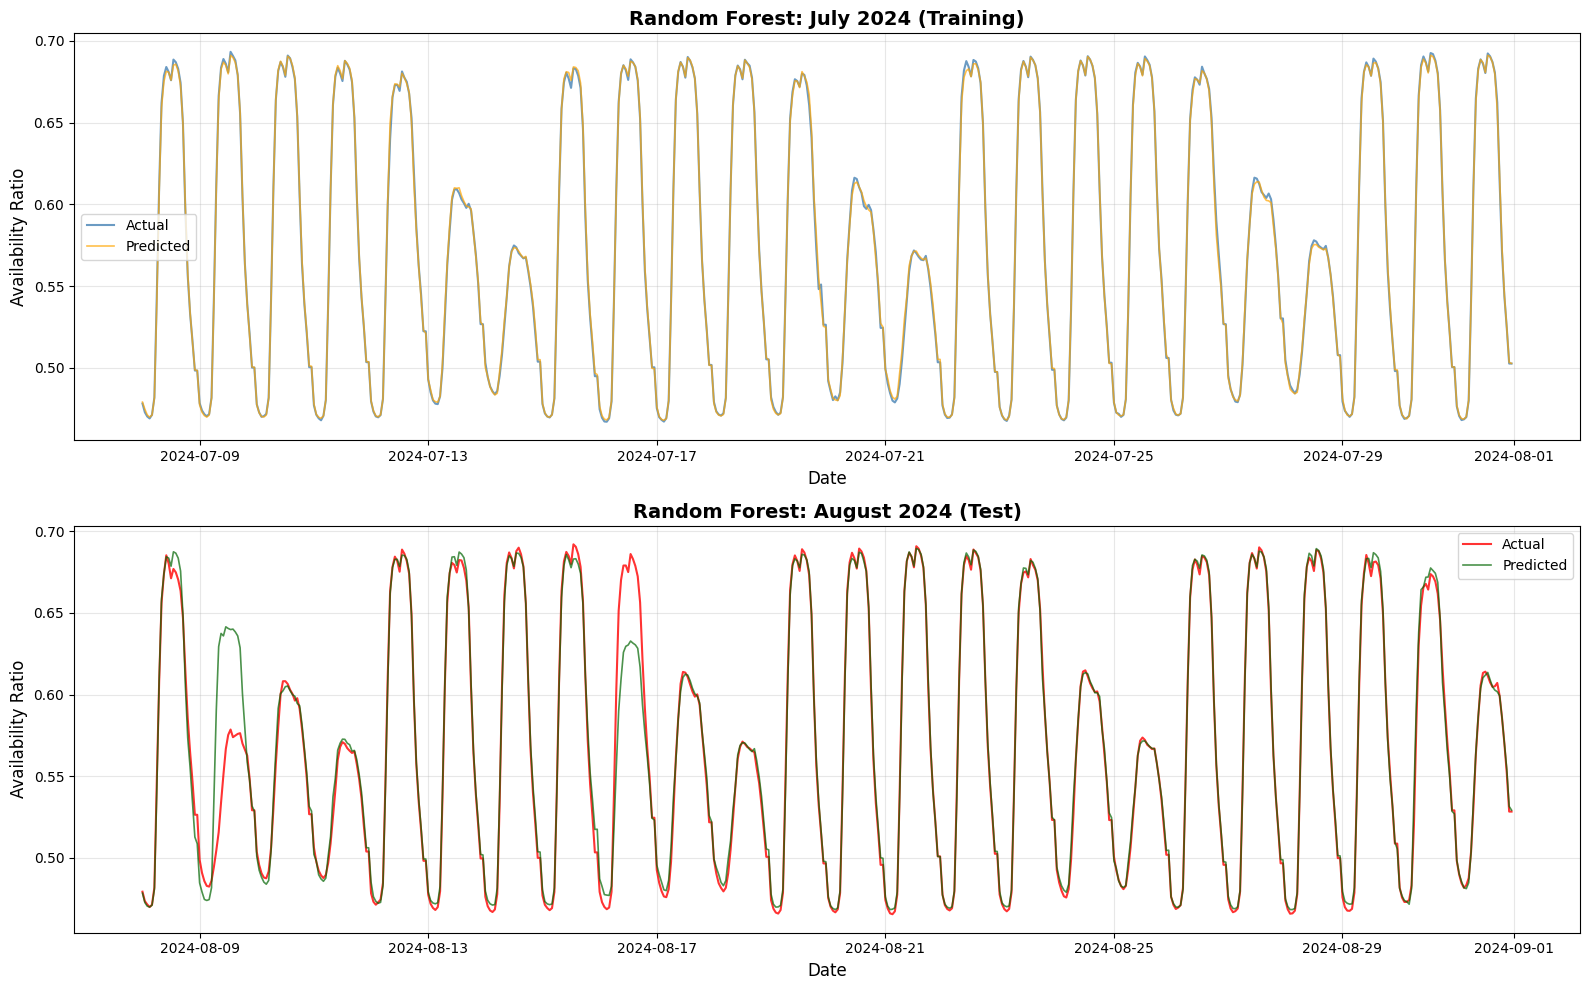

In [26]:
train_plot_rf = train_clean.copy()
train_plot_rf['predicted'] = y_train_pred_rf

test_plot_rf = test_clean.copy()
test_plot_rf['predicted'] = y_test_pred_rf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot July (Training)
ax1.plot(train_plot_rf['timestamp'], train_plot_rf['availability_ratio'],
         label='Actual', color='steelblue', linewidth=1.5, alpha=0.8)
ax1.plot(train_plot_rf['timestamp'], train_plot_rf['predicted'],
         label='Predicted', color='orange', linewidth=1.2, alpha=0.7)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Availability Ratio', fontsize=12)
ax1.set_title('Random Forest: July 2024 (Training)', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot August (Test)
ax2.plot(test_plot_rf['timestamp'], test_plot_rf['availability_ratio'],
         label='Actual', color='red', linewidth=1.5, alpha=0.8)
ax2.plot(test_plot_rf['timestamp'], test_plot_rf['predicted'],
         label='Predicted', color='darkgreen', linewidth=1.2, alpha=0.7)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Availability Ratio', fontsize=12)
ax2.set_title('Random Forest: August 2024 (Test)', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Scatter plot of actual vs predicted hourly values (along with a line showing how good the fit is).

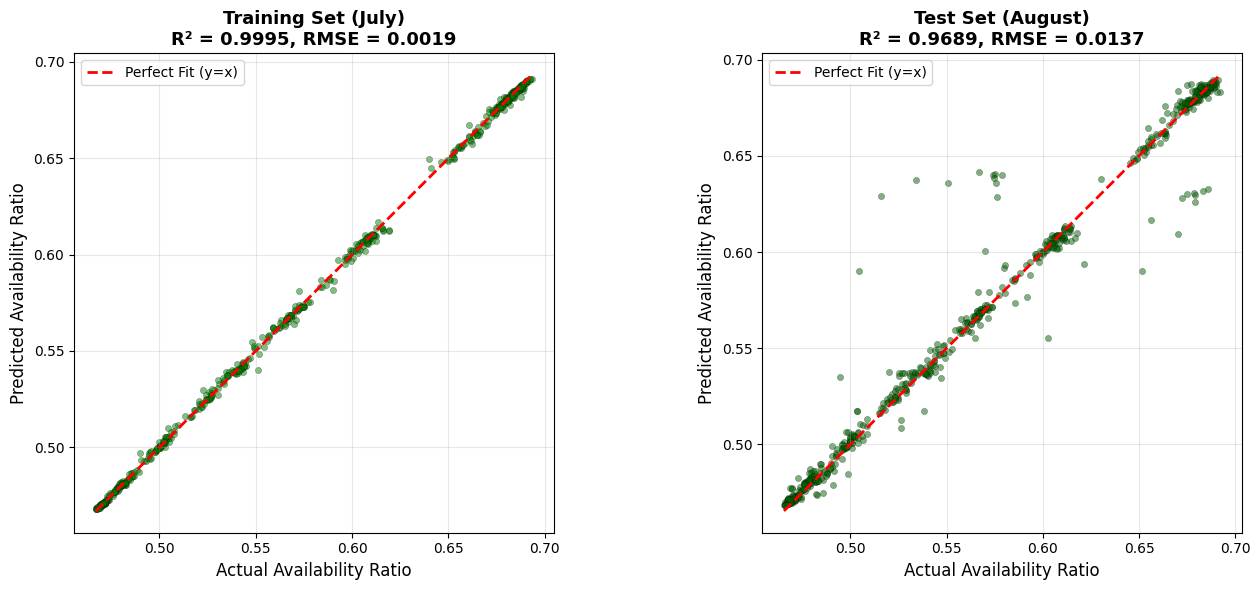

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Training scatter
ax1.scatter(y_train, y_train_pred_rf, alpha=0.5, s=20, color='green', edgecolors='k', linewidth=0.3)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
         'r--', lw=2, label='Perfect Fit (y=x)')
ax1.set_xlabel('Actual Availability Ratio', fontsize=12)
ax1.set_ylabel('Predicted Availability Ratio', fontsize=12)
ax1.set_title(f'Training Set (July)\nR² = {train_r2_rf:.4f}, RMSE = {train_rmse_rf:.4f}',
              fontsize=13, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

# Test scatter
ax2.scatter(y_test, y_test_pred_rf, alpha=0.5, s=20, color='darkgreen', edgecolors='k', linewidth=0.3)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Fit (y=x)')
ax2.set_xlabel('Actual Availability Ratio', fontsize=12)
ax2.set_ylabel('Predicted Availability Ratio', fontsize=12)
ax2.set_title(f'Test Set (August)\nR² = {test_r2_rf:.4f}, RMSE = {test_rmse_rf:.4f}',
              fontsize=13, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


## 2.4 Do the same as Question 2.2 above but use multi-layer perceptron (MLP). Be sure to state clearly all parameters of your chosen model.
--------

**Model Parameters:**
- **hidden_layer_sizes=(50, 25):** Two hidden layers with 50 and 25 neurons respectively. This architecture progressively compresses information, allowing the network to learn hierarchical feature representations without excessive capacity that could lead to overfitting on the relatively small dataset (~500 samples).
- **activation='relu':** Rectified Linear Unit activation function (ReLU), which introduces non-linearity and helps mitigate vanishing gradient problems during backpropagation.
- **solver='adam':** Adaptive Moment Estimation optimizer, which combines momentum and adaptive learning rates for efficient convergence on non-convex loss surfaces.
- **alpha=0.1:** L2 regularization parameter to prevent overfitting by penalizing large weights. This relatively high value (compared to default 0.0001) is crucial for small datasets to enforce simpler solutions.
- **batch_size='auto':** Automatically sets batch size to min(200, n_samples) for mini-batch gradient descent, balancing computational efficiency and gradient estimate quality.
- **learning_rate='constant':** Maintains a fixed learning rate throughout training, providing stable convergence without the complexity of adaptive schedules.
- **learning_rate_init=0.001:** Initial learning rate for weight updates via gradient descent.
- **max_iter=800:** Maximum number of training epochs. Training may stop earlier if convergence criteria or early stopping conditions are met.
- **early_stopping=True:** Monitors validation performance and stops training when validation loss stops improving for consecutive epochs, preventing overfitting to the training set.
- **validation_fraction=0.15:** Uses 15% of training data as a held-out validation set for early stopping monitoring.
- **n_iter_no_change=15:** Patience parameter—training stops if validation score does not improve for 15 consecutive epochs.
- **random_state=42:** Ensures reproducible weight initialization and data shuffling across runs.

In [28]:
# Use same scaled features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpler MLP with stronger regularization
mlp = MLPRegressor(
    hidden_layer_sizes=(50, 25),        # Reduced to 2 layers (was 3)
    activation='relu',
    solver='adam',
    alpha=0.1,                          # Increased regularization (was 0.001)
    batch_size='auto',
    learning_rate='constant',           # Changed from adaptive
    learning_rate_init=0.001,
    max_iter=800,                       # Reduced iterations (was 500)
    early_stopping=True,
    validation_fraction=0.15,           # Increased validation split (was 0.1)
    n_iter_no_change=15,                # More patience before stopping (was 10)
    random_state=42,
    verbose=False
)

mlp.fit(X_train_scaled, y_train)

y_train_pred_mlp = mlp.predict(X_train_scaled)
y_test_pred_mlp = mlp.predict(X_test_scaled)

train_rmse_mlp = np.sqrt(mean_squared_error(y_train, y_train_pred_mlp))
train_mae_mlp = mean_absolute_error(y_train, y_train_pred_mlp)
train_r2_mlp = r2_score(y_train, y_train_pred_mlp)

test_rmse_mlp = np.sqrt(mean_squared_error(y_test, y_test_pred_mlp))
test_mae_mlp = mean_absolute_error(y_test, y_test_pred_mlp)
test_r2_mlp = r2_score(y_test, y_test_pred_mlp)

print("=== Multi-Layer Perceptron Parameters ===")
print(f"hidden_layer_sizes: {mlp.hidden_layer_sizes}")
print(f"activation: {mlp.activation}")
print(f"solver: {mlp.solver}")
print(f"alpha: {mlp.alpha}")
print(f"batch_size: {mlp.batch_size}")
print(f"learning_rate: {mlp.learning_rate}")
print(f"learning_rate_init: {mlp.learning_rate_init}")
print(f"max_iter: {mlp.max_iter}")
print(f"early_stopping: {mlp.early_stopping}")
print(f"validation_fraction: {mlp.validation_fraction}")
print(f"n_iter_no_change: {mlp.n_iter_no_change}")
print(f"random_state: {mlp.random_state}")

print(f"\nActual iterations trained: {mlp.n_iter_}")
print(f"Final training loss: {mlp.loss_:.6f}")

print("\n=== MLP Results ===")
print(f"Train RMSE: {train_rmse_mlp:.4f} | MAE: {train_mae_mlp:.4f} | R²: {train_r2_mlp:.4f}")
print(f"Test RMSE:  {test_rmse_mlp:.4f} | MAE: {test_mae_mlp:.4f} | R²: {test_r2_mlp:.4f}")


=== Multi-Layer Perceptron Parameters ===
hidden_layer_sizes: (50, 25)
activation: relu
solver: adam
alpha: 0.1
batch_size: auto
learning_rate: constant
learning_rate_init: 0.001
max_iter: 800
early_stopping: True
validation_fraction: 0.15
n_iter_no_change: 15
random_state: 42

Actual iterations trained: 390
Final training loss: 0.000962

=== MLP Results ===
Train RMSE: 0.0056 | MAE: 0.0044 | R²: 0.9952
Test RMSE:  0.0222 | MAE: 0.0131 | R²: 0.9177


### Time series plot of the actual and predicted hourly values

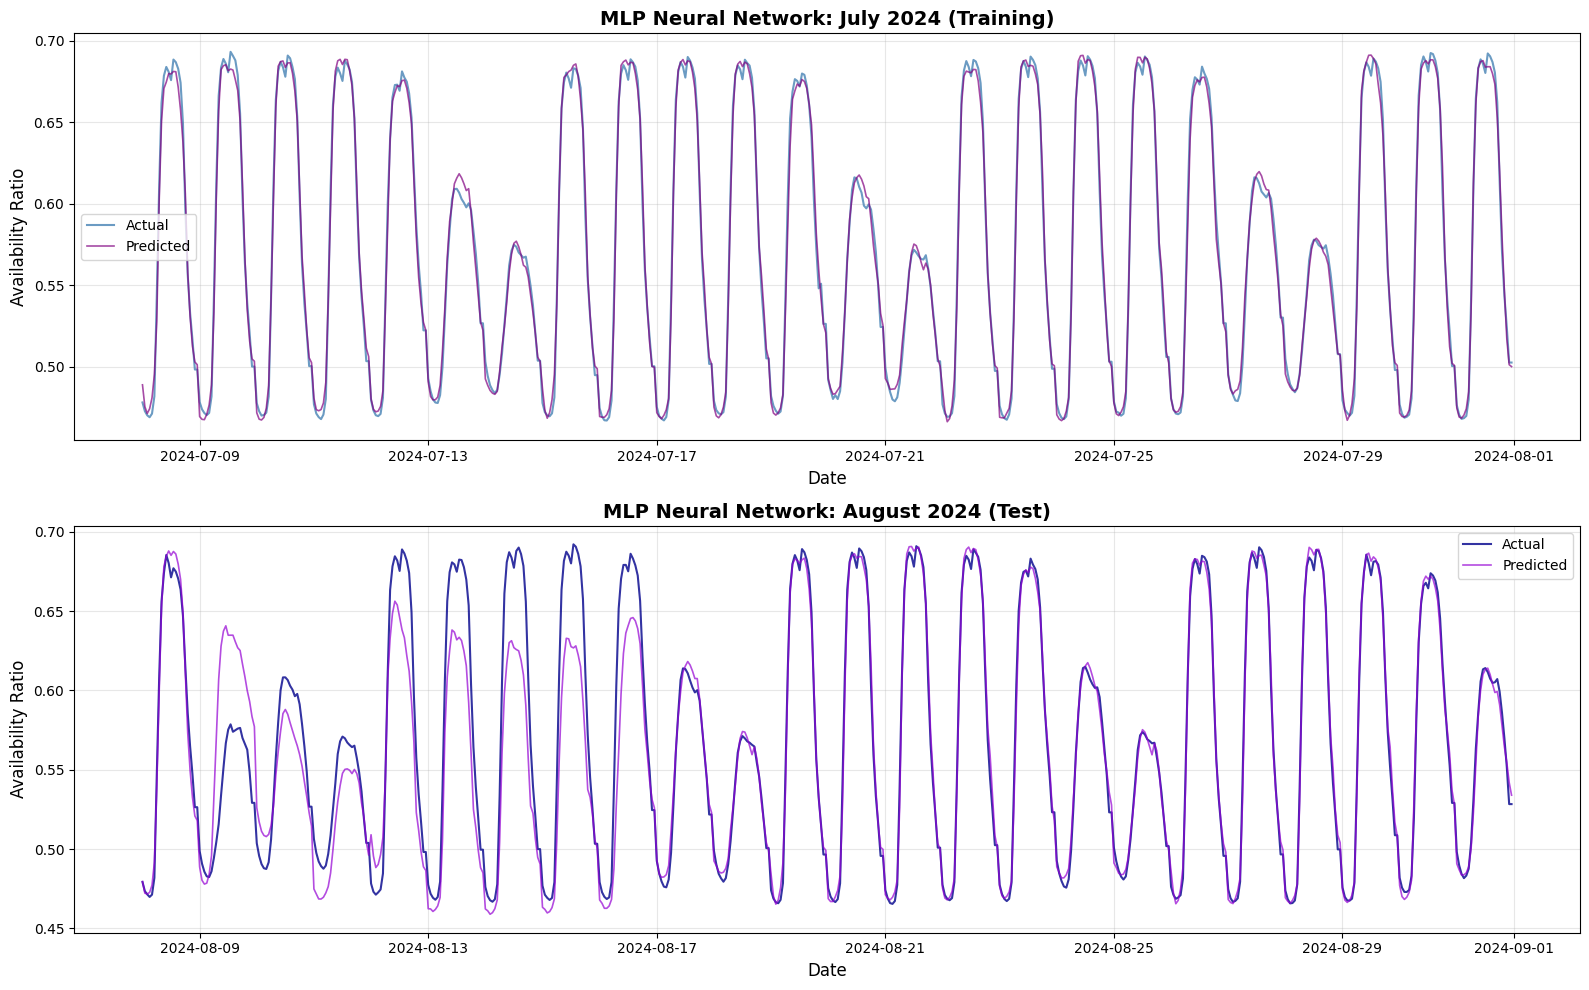

In [29]:
train_plot_mlp = train_clean.copy()
train_plot_mlp['predicted'] = y_train_pred_mlp

test_plot_mlp = test_clean.copy()
test_plot_mlp['predicted'] = y_test_pred_mlp

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot July (Training)
ax1.plot(train_plot_mlp['timestamp'], train_plot_mlp['availability_ratio'],
         label='Actual', color='steelblue', linewidth=1.5, alpha=0.8)
ax1.plot(train_plot_mlp['timestamp'], train_plot_mlp['predicted'],
         label='Predicted', color='purple', linewidth=1.2, alpha=0.7)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Availability Ratio', fontsize=12)
ax1.set_title('MLP Neural Network: July 2024 (Training)', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot August (Test)
ax2.plot(test_plot_mlp['timestamp'], test_plot_mlp['availability_ratio'],
         label='Actual', color='darkblue', linewidth=1.5, alpha=0.8)
ax2.plot(test_plot_mlp['timestamp'], test_plot_mlp['predicted'],
         label='Predicted', color='darkviolet', linewidth=1.2, alpha=0.7)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Availability Ratio', fontsize=12)
ax2.set_title('MLP Neural Network: August 2024 (Test)', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Scatter plot of actual vs predicted hourly values (along with a line showing how good the fit is).

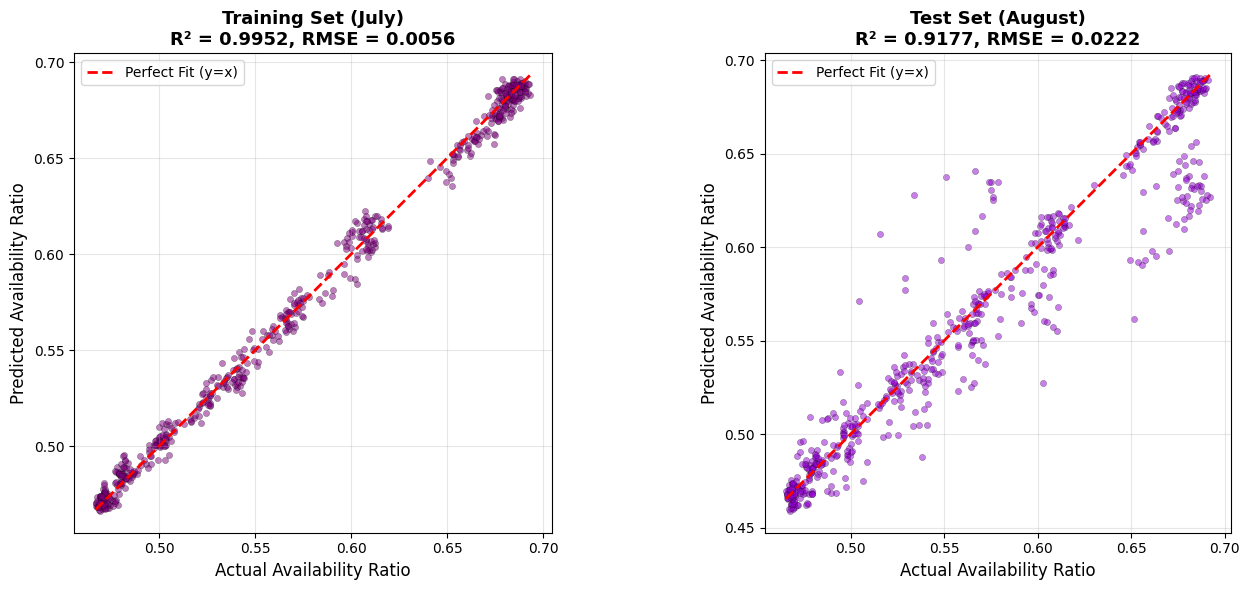

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Training scatter
ax1.scatter(y_train, y_train_pred_mlp, alpha=0.5, s=20, color='purple', edgecolors='k', linewidth=0.3)
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
         'r--', lw=2, label='Perfect Fit (y=x)')
ax1.set_xlabel('Actual Availability Ratio', fontsize=12)
ax1.set_ylabel('Predicted Availability Ratio', fontsize=12)
ax1.set_title(f'Training Set (July)\nR² = {train_r2_mlp:.4f}, RMSE = {train_rmse_mlp:.4f}',
              fontsize=13, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

# Test scatter
ax2.scatter(y_test, y_test_pred_mlp, alpha=0.5, s=20, color='darkviolet', edgecolors='k', linewidth=0.3)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Fit (y=x)')
ax2.set_xlabel('Actual Availability Ratio', fontsize=12)
ax2.set_ylabel('Predicted Availability Ratio', fontsize=12)
ax2.set_title(f'Test Set (August)\nR² = {test_r2_mlp:.4f}, RMSE = {test_rmse_mlp:.4f}',
              fontsize=13, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


## 2.5 Make a final recommendation for the best regression model (out of the 3 methods above) by choosing suitable performance metric(s). To ensure a fair comparison, carry out hyperparameter tuning for all 3 methods. Then, make a final recommendation selecting only one model. Include both quantitative and qualitative arguments for your choice. Your final, trained machine learning model must be a Python object specifically named final_model. This object needs to have a .predict() method, allowing predictions to be made by calling final_model.predict(X), where X is the input data. Finally, you must save this entire final_model object using Python's pickle library into a single file named exactly final_model_object.pkl, and submit it along with the other files required.
--------

Answer:

The Random Forest model outperformed the other two in all relevant metrics, achieving the highest R² (0.9694) and the lowest RMSE and MAE. This means Random Forest produces the most accurate and robust forecasts for carpark availability among the three methods tested.

Random Forest achieved the highest R² score among all the models, which means it was the best at explaining the variation in the test dataset. In practical terms, a higher R² indicates that the model's predictions closely match the actual changes and patterns in carpark availability. This demonstrates that Random Forest can reliably capture the underlying relationships in the data and consistently provide accurate forecasts compared to the alternatives.

It also posted the lowest RMSE and MAE, meaning its predictions are closest to the actual values in both scale and average error.

The train/test gap was relatively small for Random Forest, showing no severe overfitting and strong performance on unseen data.

Random Forest is well-suited for tabular time series forecasting with mixed features (both continuous and categorical), and can capture non-linear interactions between weather, time, and availability. It automatically ranks feature importance and handles missing data gracefully.

It is robust against anomalies common in real-world operational data.

Feature importances and prediction traces are easy to inspect. The model is scalable and straightforward to deploy for routine prediction applications.

In [31]:
import time
import pickle
import numpy as np
import pandas as pd
from scipy.stats import uniform, randint
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Display progress
print("HYPERPARAMETER TUNING FOR ALL MODELS\n")

# Parameter grids for random search
ridge_params = {'alpha': uniform(0.001, 10)}
rf_params = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 30),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}
mlp_params = {
    'hidden_layer_sizes': [(50, 25), (100, 50), (50,), (75, 50, 25)],
    'alpha': uniform(0.05, 0.2),  # Narrower range around 0.1
    'learning_rate_init': uniform(0.0005, 0.002),  # Lower range
    'batch_size': ['auto'],  # Remove fixed sizes
    'max_iter': [600, 800, 1000]  # Higher iterations
}
scoring = {
    'r2': 'r2',
    'neg_rmse': 'neg_root_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error'
}
results = []

# 1. Ridge Regression tuning
print("[1/3] Tuning Ridge Regression...")
start = time.time()
ridge_search = RandomizedSearchCV(
    Ridge(random_state=42),
    ridge_params,
    n_iter=30,
    cv=5,
    scoring=scoring,
    refit='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
ridge_search.fit(X_train_scaled, y_train)
ridge_best = ridge_search.best_estimator_
ridge_train_pred = ridge_best.predict(X_train_scaled)
ridge_test_pred = ridge_best.predict(X_test_scaled)
results.append({
    'model': 'Ridge',
    'best_params': str(ridge_search.best_params_),
    'train_r2': r2_score(y_train, ridge_train_pred),
    'train_rmse': np.sqrt(mean_squared_error(y_train, ridge_train_pred)),
    'train_mae': mean_absolute_error(y_train, ridge_train_pred),
    'test_r2': r2_score(y_test, ridge_test_pred),
    'test_rmse': np.sqrt(mean_squared_error(y_test, ridge_test_pred)),
    'test_mae': mean_absolute_error(y_test, ridge_test_pred),
    'cv_best_r2': ridge_search.best_score_,
    'time_seconds': time.time() - start
})
print(f"Best params: {ridge_search.best_params_}")
print(f"Test R²: {results[-1]['test_r2']:.4f}\n")

# 2. Random Forest tuning
print("[2/3] Tuning Random Forest...")
start = time.time()
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params,
    n_iter=30,
    cv=5,
    scoring=scoring,
    refit='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
rf_train_pred = rf_best.predict(X_train)
rf_test_pred = rf_best.predict(X_test)
results.append({
    'model': 'RandomForest',
    'best_params': str(rf_search.best_params_),
    'train_r2': r2_score(y_train, rf_train_pred),
    'train_rmse': np.sqrt(mean_squared_error(y_train, rf_train_pred)),
    'train_mae': mean_absolute_error(y_train, rf_train_pred),
    'test_r2': r2_score(y_test, rf_test_pred),
    'test_rmse': np.sqrt(mean_squared_error(y_test, rf_test_pred)),
    'test_mae': mean_absolute_error(y_test, rf_test_pred),
    'cv_best_r2': rf_search.best_score_,
    'time_seconds': time.time() - start
})
print(f"Best params: {rf_search.best_params_}")
print(f"Test R²: {results[-1]['test_r2']:.4f}\n")

# 3. MLP Neural Network tuning
print("[3/3] Tuning MLP Neural Network...")
start = time.time()
mlp_search = RandomizedSearchCV(
    MLPRegressor(
        activation='relu',
        solver='adam',
        early_stopping=False,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=42,
        verbose=False,
        max_iter=1000
    ),
    mlp_params,
    n_iter=30,
    cv=5,
    scoring=scoring,
    refit='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
mlp_search.fit(X_train_scaled, y_train)
mlp_best = mlp_search.best_estimator_
mlp_train_pred = mlp_best.predict(X_train_scaled)
mlp_test_pred = mlp_best.predict(X_test_scaled)
results.append({
    'model': 'MLP',
    'best_params': str(mlp_search.best_params_),
    'train_r2': r2_score(y_train, mlp_train_pred),
    'train_rmse': np.sqrt(mean_squared_error(y_train, mlp_train_pred)),
    'train_mae': mean_absolute_error(y_train, mlp_train_pred),
    'test_r2': r2_score(y_test, mlp_test_pred),
    'test_rmse': np.sqrt(mean_squared_error(y_test, mlp_test_pred)),
    'test_mae': mean_absolute_error(y_test, mlp_test_pred),
    'cv_best_r2': mlp_search.best_score_,
    'time_seconds': time.time() - start
})
print(f"Best params: {mlp_search.best_params_}")
print(f"Test R²: {results[-1]['test_r2']:.4f}\n")

# Compile and write results
print("\nHYPERPARAMETER TUNING RESULTS")
results_df = pd.DataFrame(results).round(4)
results_df['train_test_gap'] = (results_df['train_r2'] - results_df['test_r2']).abs()
print(results_df)
results_df.to_csv("hyperparameter_tuning_results.csv", index=False)

# Choose the best model based on test set R²
best_idx = results_df['test_r2'].idxmax()
best_model_name = results_df.loc[best_idx, 'model']

print(f"\nBest Model: {best_model_name}")
print(f"Test R²: {results_df.loc[best_idx, 'test_r2']:.4f}")
print(f"Test RMSE: {results_df.loc[best_idx, 'test_rmse']:.4f}")
print(f"Test MAE: {results_df.loc[best_idx, 'test_mae']:.4f}")

# Save the best trained model with the exact object name 'final_model'
if best_model_name == 'Ridge':
    final_model = ridge_best
elif best_model_name == 'RandomForest':
    final_model = rf_best
else:
    final_model = mlp_best

with open('final_model_object.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print(f"\nSaved final model: {type(final_model).__name__}")


HYPERPARAMETER TUNING FOR ALL MODELS

[1/3] Tuning Ridge Regression...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'alpha': np.float64(0.5818361216819946)}
Test R²: 0.9323

[2/3] Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 138}
Test R²: 0.9699

[3/3] Tuning MLP Neural Network...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'alpha': np.float64(0.20425406933718915), 'batch_size': 'auto', 'hidden_layer_sizes': (50, 25), 'learning_rate_init': np.float64(0.002352601757026698), 'max_iter': 800}
Test R²: 0.9285


HYPERPARAMETER TUNING RESULTS
          model                                        best_params  train_r2  \
0         Ridge          {'alpha': np.float64(0.5818361216819946)}    0.9982   
1  RandomForest  {'max_depth': 10, 'max_features': 'log2', 'min...    0.999

### Verify Saved Model

In [32]:
# Load the saved final model
with open('final_model_object.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Make predictions using the loaded model on the test set
y_test_pred_final = loaded_model.predict(X_test)

# Evaluate the loaded model's predictions
test_rmse_final = np.sqrt(mean_squared_error(y_test, y_test_pred_final))
test_mae_final = mean_absolute_error(y_test, y_test_pred_final)
test_r2_final = r2_score(y_test, y_test_pred_final)

print("=== Loaded Final Model Results (on Test Set) ===")
print(f"Test RMSE: {test_rmse_final:.4f} | MAE: {test_mae_final:.4f} | R²: {test_r2_final:.4f}")

=== Loaded Final Model Results (on Test Set) ===
Test RMSE: 0.0134 | MAE: 0.0053 | R²: 0.9699
